# Lab: Analyze Business Needs and Prepare Patient Data

**==============================================================**

Task 1: Review and load the datasets

Objective

Familiarize yourself with the raw data before cleaning or transforming it

Step 1: Open the data sheets

 Open Microsoft Excel and load the Patient Data and Appointment Data sheets provided

Step 2: Review the Patient_Data sheet

Scan the sheet to get familiar with the columns such as PatientID, Email, DateOfBirth, OutstandingBalance, etc.

    Look for:
        Inconsistent date formats
        Blank fields (especially in Email or DateOfBirth)
        Unusual values such as negative balances or non-standard location names

Step 3: Review the Appointment_Data sheet

    Check for columns such as AppointmentID, AppointmentDate, ClinicLocation, and AppointmentFee
    Look for:
        Currency symbols or non-numeric entries in the AppointmentFee column
        Duplicate appointment IDs
        Blank or inconsistent AppointmentDate values


**===========================================**

## Import Libraries

In [1]:
import numpy as np
#from numpy import count_nonzero, median, mean
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
#import squarify

# Plotly
import plotly.express as px
import plotly.offline as py
import plotly.graph_objs as go


#import statsmodels.api as sm
#import statsmodels.formula.api as smf
# from statsmodels.formula.api import ols
# Import variance_inflation_factor from statsmodels
#from statsmodels.stats.outliers_influence import variance_inflation_factor
# Import Tukey's HSD function
#from statsmodels.stats.multicomp import pairwise_tukeyhsd

import datetime
from datetime import datetime, timedelta, date


#import os
#import zipfile
import scipy
from scipy import stats
from scipy.stats.mstats import normaltest # D'Agostino K^2 Test
from scipy.stats import boxcox
from collections import Counter

# Use Folium library to plot values on a map.
#import folium

%matplotlib inline
#sets the default autosave frequency in seconds
%autosave 60 
sns.set_style('dark')
sns.set(font_scale=1.2)
#sns.set(rc={'figure.figsize':(14,10)})

plt.rc('axes', titlesize=9)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
#pd.set_option('display.max_rows',None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format','{:.2f}'.format)

random.seed(0)
np.random.seed(0)
np.set_printoptions(suppress=True)

Autosaving every 60 seconds


**===========================================================**

## Import Data

In [2]:
df = pd.read_csv("Patient_Data.csv")

In [3]:
df

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance
0,101,Alice Johnson,alice.j@example.com,5/21/1990,ACCT-10002345,Individual,BR001,US,1/15/2020,12000
1,102,Bob Smith,bob.smith@xyz.com,8/15/1985,ACCT-10005678,Family,BR002,United States,11/30/2019,3000
2,103,Cathy Davis,cathy.davis@example.com,11/3/1992,ACCT-10007891,Individual,BR003,US,6/1/2021,8500
3,104,David Lee,david.l@xyz.com,2/28/1978,ACCT-10001234,Individual,BR004,US,3/20/2021,5000
4,105,Eva Turner,NaN,4/7/1989,ACCT-10003456,Family,BR005,United States,7/19/2020,-1000
5,106,Frank Zhang,frank.zhang@xyz.com,12/13/1975,ACCT-10004567,Individual,BR006,U.S.,9/11/2018,7500
6,107,Gina King,gina.k@example.com,3/20/1993,ACCT-10008901,Individual,BR007,Canada,1/9/2022,20000
7,108,Harry Brown,harry.b@xyz.com,9/15/1987,ACCT-10006789,Family,BR008,US,8/21/2020,3500
8,109,Ivy Scott,ivy.scott@example.com,NaN,ACCT-10009876,Individual,BR009,Canada,11/14/2021,8000
9,110,John Doe,NaN,1/1/1990,ACCT-10005432,Individual,BR010,United States,3/29/2022,not available


## Task 2: Clean the Patient_Data sheet

Objective

Improve the quality of the patient dataset by removing duplicates, handling missing data, and standardizing key fields

Step 1: Remove duplicates

Remove duplicate entries using the Remove Duplicates feature in Excel, with PatientID as the key column since each patient should appear only once in the dataset

Step 2: Handle missing values

    Identify and fill missing values in the Email and DateOfBirth columns
    Use filtering to locate blanks. Enter "No Email Provided" where needed
    Leave missing birthdates for manual review

Step 3: Standardize date formats

    Format DateOfBirth and RegistrationDate columns to a consistent MM/DD/YYYY format

Step 4: Correct location names using US_Cities

    Standardize variations of "United States" using Find and Replace. Refer to the US_Cities sheet for consistency

Step 5: Validate billing values in OutstandingBalance

    Check for and fix negative or non-numeric values in the OutstandingBalance column. Replace invalid entries with 0 as needed

**============================================================**

## Data Quick Glance

In [4]:
df.head()

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance
0,101,Alice Johnson,alice.j@example.com,5/21/1990,ACCT-10002345,Individual,BR001,US,1/15/2020,12000
1,102,Bob Smith,bob.smith@xyz.com,8/15/1985,ACCT-10005678,Family,BR002,United States,11/30/2019,3000
2,103,Cathy Davis,cathy.davis@example.com,11/3/1992,ACCT-10007891,Individual,BR003,US,6/1/2021,8500
3,104,David Lee,david.l@xyz.com,2/28/1978,ACCT-10001234,Individual,BR004,US,3/20/2021,5000
4,105,Eva Turner,NaN,4/7/1989,ACCT-10003456,Family,BR005,United States,7/19/2020,-1000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   PatientID           20 non-null     int64 
 1   PatientName         20 non-null     object
 2   Email               16 non-null     object
 3   DateOfBirth         18 non-null     object
 4   AccountID           20 non-null     object
 5   AccountType         20 non-null     object
 6   BranchCode          20 non-null     object
 7   Location            20 non-null     object
 8   RegistrationDate    20 non-null     object
 9   OutstandingBalance  20 non-null     object
dtypes: int64(1), object(9)
memory usage: 1.7+ KB


In [6]:
df["PatientID"].value_counts()

PatientID
101    1
102    1
119    1
118    1
117    1
116    1
115    1
114    1
113    1
112    1
111    1
110    1
109    1
108    1
107    1
106    1
105    1
104    1
103    1
120    1
Name: count, dtype: int64

In [7]:
list(df["PatientID"])

[101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120]

In [8]:
df.dtypes.value_counts()

object    9
int64     1
Name: count, dtype: int64

In [9]:
df.isnull().sum()

PatientID             0
PatientName           0
Email                 4
DateOfBirth           2
AccountID             0
AccountType           0
BranchCode            0
Location              0
RegistrationDate      0
OutstandingBalance    0
dtype: int64

In [10]:
df["Email"].fillna("No Email Provided", inplace=True)

In [11]:
df["DateOfBirth"] = pd.to_datetime(df["DateOfBirth"])

In [12]:
df["Location"]

0                 US
1      United States
2                 US
3                 US
4      United States
5               U.S.
6             Canada
7                 US
8             Canada
9      United States
10            U.S.A.
11    United Kingdom
12                US
13            Canada
14     United States
15         Australia
16                UK
17       New Zealand
18    United Kingdom
19            Canada
Name: Location, dtype: object

In [13]:
# Define mapping dictionary
country_map = {
    "US": "United States",
    "U.S.": "United States",
    "U.S.A.": "United States",
    "UK": "United Kingdom"
}

# Apply the mapping
df["Location"] = df["Location"].replace(country_map)

In [14]:
df["Location"]

0      United States
1      United States
2      United States
3      United States
4      United States
5      United States
6             Canada
7      United States
8             Canada
9      United States
10     United States
11    United Kingdom
12     United States
13            Canada
14     United States
15         Australia
16    United Kingdom
17       New Zealand
18    United Kingdom
19            Canada
Name: Location, dtype: object

In [15]:
df["OutstandingBalance"]

0             12000
1              3000
2              8500
3              5000
4             -1000
5              7500
6             20000
7              3500
8              8000
9     not available
10             6000
11             5500
12             4000
13            10000
14             1500
15             -500
16            23000
17             8700
18              500
19             9200
Name: OutstandingBalance, dtype: object

In [16]:
df["OutstandingBalance"] = df["OutstandingBalance"].replace(to_replace="not available", value=0)

In [17]:
df["OutstandingBalance"] = pd.to_numeric(df["OutstandingBalance"], errors="coerce")

In [18]:
df["OutstandingBalance"] > 0

0      True
1      True
2      True
3      True
4     False
5      True
6      True
7      True
8      True
9     False
10     True
11     True
12     True
13     True
14     True
15    False
16     True
17     True
18     True
19     True
Name: OutstandingBalance, dtype: bool

In [19]:
df.loc[df["OutstandingBalance"] < 0, "OutstandingBalance"] = 0

In [20]:
df.head()

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000
1,102,Bob Smith,bob.smith@xyz.com,1985-08-15,ACCT-10005678,Family,BR002,United States,11/30/2019,3000
2,103,Cathy Davis,cathy.davis@example.com,1992-11-03,ACCT-10007891,Individual,BR003,United States,6/1/2021,8500
3,104,David Lee,david.l@xyz.com,1978-02-28,ACCT-10001234,Individual,BR004,United States,3/20/2021,5000
4,105,Eva Turner,No Email Provided,1989-04-07,ACCT-10003456,Family,BR005,United States,7/19/2020,0


In [21]:
#df.to_csv("Patient_Data_Cleaned.csv", index=False)

**================================================================**

## Task 3: Clean the Appointment_Data sheet

Objective

Ensure data consistency in appointment scheduling and billing fields

Step 1: Remove duplicate appointment records

    Remove duplicate entries using the Remove Duplicates feature in Excel, with AppointmentID as the key column since each appointment should appear only once in the dataset. 

Step 2: Standardize date formats in AppointmentDate

    Format the AppointmentDate column to MM/DD/YYYY
    Check for inconsistent formats and confirm proper conversion

Step 3: Clean and validate AppointmentFee values

    Remove symbols or text (e.g., $, "not available") from the AppointmentFee column
    Filter to detect non-numeric or blank entries
    Replace invalid or negative values with 0, since appointment fees cannot be negative

Step 4: Standardize clinic location names using the Branch sheet

    Use the ClinicLocation column and cross-check with the Branch sheet for correct clinic names
    Use Find and Replace to update common variants (e.g., NY to New York)
    Align all entries with standard naming conventions

In [22]:
df2 = pd.read_csv("Appointment_Data.csv")

In [23]:
df2.head()

,AppointmentID,AccountID,AppointmentDate,AppointmentType,AppointmentFee,ClinicLocation
0,201,ACCT-10002345,1/5/2022,Consultation,$500,NY
1,202,ACCT-10005678,2/15/2022,Follow-up,200,New York
2,203,ACCT-10007891,15-Mar-22,Consultation,300,LA
3,204,ACCT-10001234,4/10/2022,Follow-up,-400,Cincinnati
4,205,ACCT-10003456,4/30/2022,Consultation,450,SF


In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   AppointmentID    20 non-null     int64 
 1   AccountID        20 non-null     object
 2   AppointmentDate  20 non-null     object
 3   AppointmentType  20 non-null     object
 4   AppointmentFee   20 non-null     object
 5   ClinicLocation   20 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.1+ KB


In [25]:
df2["AppointmentID"].value_counts()

AppointmentID
201    1
202    1
219    1
218    1
217    1
216    1
215    1
214    1
213    1
212    1
211    1
210    1
209    1
208    1
207    1
206    1
205    1
204    1
203    1
220    1
Name: count, dtype: int64

In [26]:
df2["AppointmentDate"] = pd.to_datetime(df2["AppointmentDate"], errors='coerce')

In [27]:
df2["AppointmentFee"]

0              $500
1               200
2               300
3              -400
4               450
5               100
6               750
7               200
8               600
9     not available
10              400
11              100
12              250
13             1000
14             -200
15              500
16              800
17              700
18              350
19             $600
Name: AppointmentFee, dtype: object

In [28]:
df2["AppointmentFee"] = df2["AppointmentFee"].replace(to_replace="not available", value=0)

In [29]:
df2["AppointmentFee"] = df2["AppointmentFee"].replace(to_replace="$500", value=500)

In [30]:
df2["AppointmentFee"] = df2["AppointmentFee"].replace(to_replace="$600", value=600)

In [31]:
df2["AppointmentFee"] = pd.to_numeric(df2["AppointmentFee"], errors="coerce")

In [32]:
df2.loc[df2["AppointmentFee"] < 0, "AppointmentFee"] = 0

In [33]:
df2["ClinicLocation"]

0             NY
1       New York
2             LA
3     Cincinnati
4             SF
5          Texas
6            DAL
7         Dallas
8             NY
9       New York
10            SF
11            SF
12            LA
13    Cincinnati
14           DAL
15        Dallas
16            NY
17            NY
18            SF
19            SF
Name: ClinicLocation, dtype: object

In [34]:
# Define mapping dictionary
branch_map = {
    "NY": "New York",
    "DAL": "Dallas",
    "SF": "San Francisco",
    "LA": "Los Angeles"
}

# Apply the mapping
df2["ClinicLocation"] = df2["ClinicLocation"].replace(branch_map)

In [35]:
df2

,AppointmentID,AccountID,AppointmentDate,AppointmentType,AppointmentFee,ClinicLocation
0,201,ACCT-10002345,2022-01-05,Consultation,500,New York
1,202,ACCT-10005678,2022-02-15,Follow-up,200,New York
2,203,ACCT-10007891,NaT,Consultation,300,Los Angeles
3,204,ACCT-10001234,2022-04-10,Follow-up,0,Cincinnati
4,205,ACCT-10003456,2022-04-30,Consultation,450,San Francisco
5,206,ACCT-10004567,2022-05-20,Follow-up,100,Texas
6,207,ACCT-10008901,2022-06-25,Consultation,750,Dallas
7,208,ACCT-10006789,2022-07-05,Follow-up,200,Dallas
8,209,ACCT-10009876,2022-08-15,Consultation,600,New York
9,210,ACCT-10005432,2022-09-01,Follow-up,0,New York


In [36]:
#df2.to_csv("Appointment_Data_Cleaned.csv", index=False)

**============================**

In [37]:
df = pd.read_csv("Patient_Data_Cleaned.csv", parse_dates=["DateOfBirth"])

In [38]:
df.head()

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000
1,102,Bob Smith,bob.smith@xyz.com,1985-08-15,ACCT-10005678,Family,BR002,United States,11/30/2019,3000
2,103,Cathy Davis,cathy.davis@example.com,1992-11-03,ACCT-10007891,Individual,BR003,United States,6/1/2021,8500
3,104,David Lee,david.l@xyz.com,1978-02-28,ACCT-10001234,Individual,BR004,United States,3/20/2021,5000
4,105,Eva Turner,No Email Provided,1989-04-07,ACCT-10003456,Family,BR005,United States,7/19/2020,0


In [39]:
df.columns

Index(['PatientID', 'PatientName', 'Email', 'DateOfBirth', 'AccountID', 'AccountType', 'BranchCode', 'Location', 'RegistrationDate', 'OutstandingBalance'], dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   PatientID           20 non-null     int64         
 1   PatientName         20 non-null     object        
 2   Email               20 non-null     object        
 3   DateOfBirth         18 non-null     datetime64[ns]
 4   AccountID           20 non-null     object        
 5   AccountType         20 non-null     object        
 6   BranchCode          20 non-null     object        
 7   Location            20 non-null     object        
 8   RegistrationDate    20 non-null     object        
 9   OutstandingBalance  20 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 1.7+ KB


In [41]:
from datetime import datetime

In [42]:
# Calculate age
today = pd.Timestamp(datetime.today().date())
df["PatientAge"] = df["DateOfBirth"].apply(lambda dob: today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day)) if pd.notnull(dob) else None)

In [43]:
df.head()

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance,PatientAge
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000,35.00
1,102,Bob Smith,bob.smith@xyz.com,1985-08-15,ACCT-10005678,Family,BR002,United States,11/30/2019,3000,40.00
2,103,Cathy Davis,cathy.davis@example.com,1992-11-03,ACCT-10007891,Individual,BR003,United States,6/1/2021,8500,32.00
3,104,David Lee,david.l@xyz.com,1978-02-28,ACCT-10001234,Individual,BR004,United States,3/20/2021,5000,47.00
4,105,Eva Turner,No Email Provided,1989-04-07,ACCT-10003456,Family,BR005,United States,7/19/2020,0,36.00


In [44]:
# Categorize balance
def categorize_balance(balance):
    if pd.isnull(balance):
        return None
    elif balance <= 500:
        return "Low Balance"
    elif balance <= 2000:
        return "Medium Balance"
    else:
        return "High Balance"

df["BalanceCategory"] = df["OutstandingBalance"].apply(categorize_balance)



In [45]:
df.head()

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance,PatientAge,BalanceCategory
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000,35.00,High Balance
1,102,Bob Smith,bob.smith@xyz.com,1985-08-15,ACCT-10005678,Family,BR002,United States,11/30/2019,3000,40.00,High Balance
2,103,Cathy Davis,cathy.davis@example.com,1992-11-03,ACCT-10007891,Individual,BR003,United States,6/1/2021,8500,32.00,High Balance
3,104,David Lee,david.l@xyz.com,1978-02-28,ACCT-10001234,Individual,BR004,United States,3/20/2021,5000,47.00,High Balance
4,105,Eva Turner,No Email Provided,1989-04-07,ACCT-10003456,Family,BR005,United States,7/19/2020,0,36.00,Low Balance


In [46]:
df2 = pd.read_csv("Appointment_Data_Cleaned.csv", parse_dates=["AppointmentDate"])

In [47]:
df2.head()

,AppointmentID,AccountID,AppointmentDate,AppointmentType,AppointmentFee,ClinicLocation
0,201,ACCT-10002345,2022-01-05,Consultation,500,New York
1,202,ACCT-10005678,2022-02-15,Follow-up,200,New York
2,203,ACCT-10007891,NaT,Consultation,300,Los Angeles
3,204,ACCT-10001234,2022-04-10,Follow-up,0,Cincinnati
4,205,ACCT-10003456,2022-04-30,Consultation,450,San Francisco


In [48]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   AppointmentID    20 non-null     int64         
 1   AccountID        20 non-null     object        
 2   AppointmentDate  18 non-null     datetime64[ns]
 3   AppointmentType  20 non-null     object        
 4   AppointmentFee   20 non-null     int64         
 5   ClinicLocation   20 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 1.1+ KB


In [49]:
# Fill NaT values with today's date
df2["AppointmentDate"] = df2["AppointmentDate"].fillna(pd.Timestamp.today().normalize())

In [50]:
df2["AppointmentMonth"] = df2["AppointmentDate"].dt.strftime("%B")

In [51]:
df2.head()

,AppointmentID,AccountID,AppointmentDate,AppointmentType,AppointmentFee,ClinicLocation,AppointmentMonth
0,201,ACCT-10002345,2022-01-05,Consultation,500,New York,January
1,202,ACCT-10005678,2022-02-15,Follow-up,200,New York,February
2,203,ACCT-10007891,2025-09-05,Consultation,300,Los Angeles,September
3,204,ACCT-10001234,2022-04-10,Follow-up,0,Cincinnati,April
4,205,ACCT-10003456,2022-04-30,Consultation,450,San Francisco,April


In [52]:
# Step 1: Extract unique AccountIDs from Appointment_Data
account_ids = df2["AccountID"].unique()

# Step 2: Flag patients with appointments
df["HasAppointment"] = df["AccountID"].isin(account_ids)


In [53]:
df

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance,PatientAge,BalanceCategory,HasAppointment
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000,35.00,High Balance,True
1,102,Bob Smith,bob.smith@xyz.com,1985-08-15,ACCT-10005678,Family,BR002,United States,11/30/2019,3000,40.00,High Balance,True
2,103,Cathy Davis,cathy.davis@example.com,1992-11-03,ACCT-10007891,Individual,BR003,United States,6/1/2021,8500,32.00,High Balance,True
3,104,David Lee,david.l@xyz.com,1978-02-28,ACCT-10001234,Individual,BR004,United States,3/20/2021,5000,47.00,High Balance,True
4,105,Eva Turner,No Email Provided,1989-04-07,ACCT-10003456,Family,BR005,United States,7/19/2020,0,36.00,Low Balance,True
5,106,Frank Zhang,frank.zhang@xyz.com,1975-12-13,ACCT-10004567,Individual,BR006,United States,9/11/2018,7500,49.00,High Balance,True
6,107,Gina King,gina.k@example.com,1993-03-20,ACCT-10008901,Individual,BR007,Canada,1/9/2022,20000,32.00,High Balance,True
7,108,Harry Brown,harry.b@xyz.com,1987-09-15,ACCT-10006789,Family,BR008,United States,8/21/2020,3500,37.00,High Balance,True
8,109,Ivy Scott,ivy.scott@example.com,NaT,ACCT-10009876,Individual,BR009,Canada,11/14/2021,8000,NaN,High Balance,True
9,110,John Doe,No Email Provided,1990-01-01,ACCT-10005432,Individual,BR010,United States,3/29/2022,0,35.00,Low Balance,True


In [54]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AppointmentID     20 non-null     int64         
 1   AccountID         20 non-null     object        
 2   AppointmentDate   20 non-null     datetime64[ns]
 3   AppointmentType   20 non-null     object        
 4   AppointmentFee    20 non-null     int64         
 5   ClinicLocation    20 non-null     object        
 6   AppointmentMonth  20 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 1.2+ KB


In [55]:
# Flag fees greater than 750
df2["FeeFlagHigh"] = df2["AppointmentFee"] > 750

# Flag negative fees
df2["FeeFlagNegative"] = df2["AppointmentFee"] < 0

In [56]:
df2

,AppointmentID,AccountID,AppointmentDate,AppointmentType,AppointmentFee,ClinicLocation,AppointmentMonth,FeeFlagHigh,FeeFlagNegative
0,201,ACCT-10002345,2022-01-05,Consultation,500,New York,January,False,False
1,202,ACCT-10005678,2022-02-15,Follow-up,200,New York,February,False,False
2,203,ACCT-10007891,2025-09-05,Consultation,300,Los Angeles,September,False,False
3,204,ACCT-10001234,2022-04-10,Follow-up,0,Cincinnati,April,False,False
4,205,ACCT-10003456,2022-04-30,Consultation,450,San Francisco,April,False,False
5,206,ACCT-10004567,2022-05-20,Follow-up,100,Texas,May,False,False
6,207,ACCT-10008901,2022-06-25,Consultation,750,Dallas,June,False,False
7,208,ACCT-10006789,2022-07-05,Follow-up,200,Dallas,July,False,False
8,209,ACCT-10009876,2022-08-15,Consultation,600,New York,August,False,False
9,210,ACCT-10005432,2022-09-01,Follow-up,0,New York,September,False,False


**===============================**

In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AppointmentID     20 non-null     int64         
 1   AccountID         20 non-null     object        
 2   AppointmentDate   20 non-null     datetime64[ns]
 3   AppointmentType   20 non-null     object        
 4   AppointmentFee    20 non-null     int64         
 5   ClinicLocation    20 non-null     object        
 6   AppointmentMonth  20 non-null     object        
 7   FeeFlagHigh       20 non-null     bool          
 8   FeeFlagNegative   20 non-null     bool          
dtypes: bool(2), datetime64[ns](1), int64(2), object(4)
memory usage: 1.3+ KB


**================**

## Part 2: Create key visualizations

Task 1: Patient age distribution

Visualize the spread of patient ages using a bar or column chart.


In [60]:
df.columns

Index(['PatientID', 'PatientName', 'Email', 'DateOfBirth', 'AccountID', 'AccountType', 'BranchCode', 'Location', 'RegistrationDate', 'OutstandingBalance', 'PatientAge', 'BalanceCategory', 'HasAppointment'], dtype='object')

In [63]:
# Define age bins and labels
age_bins = [0, 17, 25, 35, 50, float("inf")]
age_labels = ["Under 18", "18–25", "26–35", "36–50", "51+"]

# Create age bracket column
df["AgeBracket"] = pd.cut(df["PatientAge"], bins=age_bins, labels=age_labels, right=True)


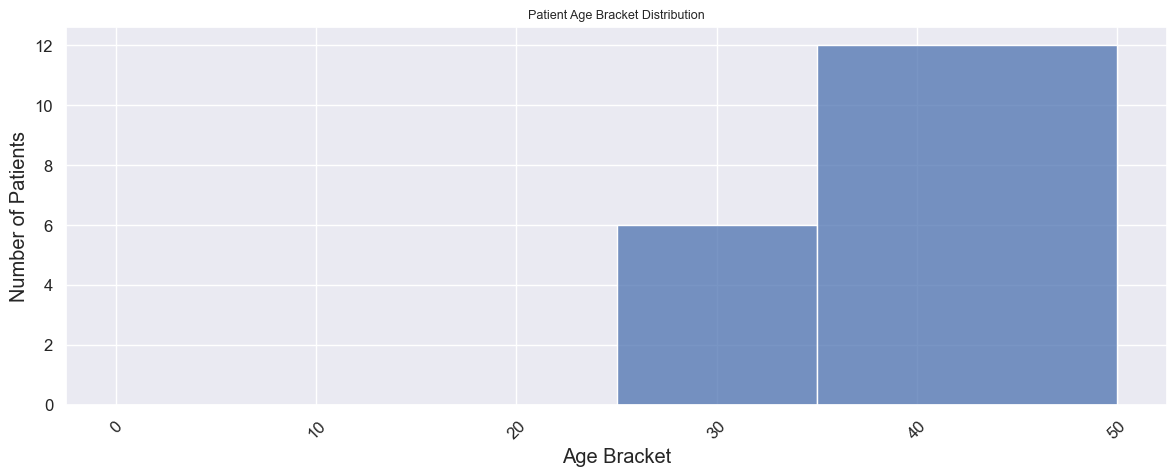

In [66]:
fig, ax = plt.subplots(figsize=(12,5))

sns.histplot(x=df.PatientAge, data=df, bins=age_bins, palette="Blues")

plt.title("Patient Age Bracket Distribution")
plt.xlabel("Age Bracket")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.show()

In [67]:
df.head(1)

,PatientID,PatientName,Email,DateOfBirth,AccountID,AccountType,BranchCode,Location,RegistrationDate,OutstandingBalance,PatientAge,BalanceCategory,HasAppointment,AgeBracket
0,101,Alice Johnson,alice.j@example.com,1990-05-21,ACCT-10002345,Individual,BR001,United States,1/15/2020,12000,35.00,High Balance,True,26–35


In [71]:
# Group by AgeBracket and count PatientID
age_summary = df.groupby("AgeBracket")["PatientID"].count().reset_index()

# Rename for clarity
age_summary.columns = ["AgeGroup", "PatientCount"]

In [73]:
age_summary

,AgeGroup,PatientCount
0,Under 18,0
1,18–25,0
2,26–35,8
3,36–50,10
4,51+,0


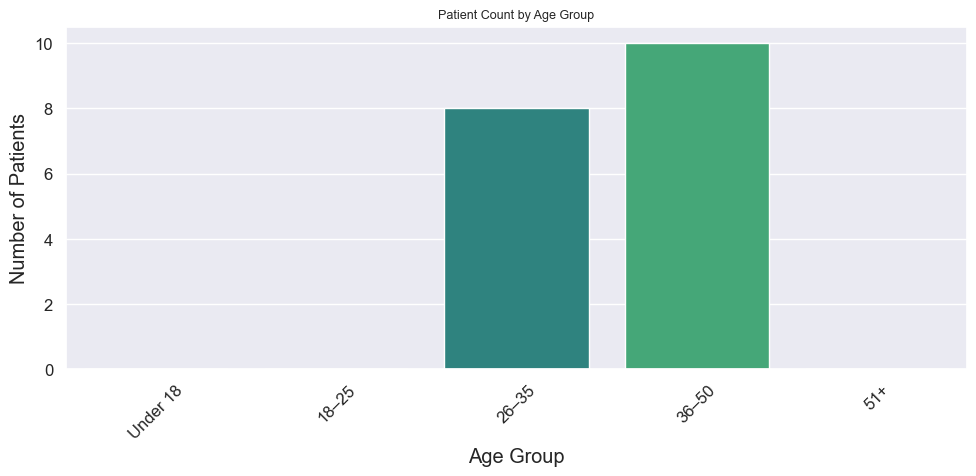

In [74]:
# Set up plot
plt.figure(figsize=(10, 5))
sns.barplot(x="AgeGroup", y="PatientCount", data=age_summary, palette="viridis")

# Add labels and title
plt.title("Patient Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
sns.catplot(x="txndescription", y="amount", kind='bar', data=df, hue ='gender', aspect=2, height=6)
plt.show()

In [ ]:
sns.catplot(x="txndescription", y="amount", kind='bar', data=df, hue ='gender', aspect=2, height=6, palette="viridis")
plt.show()

In [ ]:
# Plot 4 rows and 1 column (can be expanded)

fig, ax = plt.subplots(4,1, sharex=False, figsize=(16,16))
fig.suptitle('Main Title', y=1.0)


sns.barplot(x="txndescription", y="amount", hue=None, ci=95, data=df, orient=None, ax=ax[0])
ax[0].set_title('Title of the first chart')
#ax[0].tick_params('x', labelrotation=45)
ax[0].set_xlabel("")
ax[0].set_ylabel("")

sns.barplot(x="gender", y="amount", hue=None, ci=95, data=df, orient=None, ax=ax[1])
ax[1].set_title('Title of the second chart')
#ax[1].tick_params('x', labelrotation=45)
ax[1].set_xlabel("")
ax[1].set_ylabel("")

sns.barplot(x="merchantstate", y="amount", hue=None, ci=95, data=df, orient=None, ax=ax[2])
ax[2].set_title('Title of the third chart')
#ax[2].tick_params('x', labelrotation=45)
ax[2].set_xlabel("")
ax[2].set_ylabel("")

sns.barplot(x="movement", y="amount", hue=None, ci=95, data=df, ax=ax[3])
ax[3].set_title('Title of the fourth chart')
#ax[3].tick_params('x', labelrotation=45)
ax[3].set_xlabel("")
ax[3].set_ylabel("")

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Sort Barplots by Values and Single Plot

fig = plt.figure(figsize=(20,10))


sns.barplot(x=None, y=df.vendorid2, data=df,
            order=df.sort_values('vendorid2', ascending=False).index)
plt.title("", size=20)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Side by Side Bar Plots

In [ ]:
df4 = pd.melt(df3, id_vars="cardID")
df4

In [ ]:
plt.figure(figsize=(20,5))
sns.factorplot(x = 'a', y='b', hue="c" , data=df4, kind='bar')
plt.show()

## Horizontal/Vertical Stacked Column Bar Chart

In [ ]:
# Create a stacked bar plot to visualize number of employees across department, comparing those who left with those who didn't
# In the legend, 0 (purple color) represents employees who did not leave, 1 (red color) represents employees who left
pd.crosstab(df1["department"], df1["left"]).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

**==========================================================================================================**

## Scatter Plots

A `scatter plot` (2D) is a useful method of comparing variables against each other. `Scatter` plots look similar to `line plots` in that they both map independent and dependent variables on a 2D graph. While the data points are connected together by a line in a line plot, they are not connected in a scatter plot. The data in a scatter plot is considered to express a trend. With further analysis using tools like regression, we can mathematically calculate this relationship and use it to predict trends outside the dataset.

### Pandas Version

In [ ]:
df2.head()

In [ ]:
df2.plot.scatter(x="infant_mortality" , y="life_expectancy", c=None, figsize=(12,8))

plt.show()

In [ ]:
df2.plot.scatter(x="infant_mortality" , y="life_expectancy", c="fertility", figsize=(12,8))

plt.show()

In [ ]:
ax = df2.plot.scatter(x="infant_mortality" , y="life_expectancy", figsize=(12,8))
df2.plot.scatter(x="infant_mortality" , y="pop", ax=ax, color='r')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
df.plot(kind="scatter", x="amount", y="balance", color=(0.0, 0.0, 0.8), label='Inline label', ax=ax)

ax.set(title="title",
       xlabel="x",
       ylabel="y")

ax.axhline(y=100000, linewidth=3, color="red", linestyle="--")
ax.legend()
ax.set_xlim([0, 2000])
ax.set_ylim([0, 150000])
plt.show()

In [ ]:
#Plot 2 by 2 subplots

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, sharex=False, sharey=False, figsize=(20,15))
fig.suptitle('Main Title', y=1.0, size = 20)

df.plot.scatter(x="age", y="amount", s=None, c='b', ax=ax1)
ax1.set_title("Title")
ax1.set(xlabel="x", ylabel="y")
#ax1.set_xlim([0, 0])
#ax1.set_ylim([0, 0])

df.plot.scatter(x="age", y="amount", s=None, c='b', ax=ax2)
ax2.set_title("Title")
ax2.set(xlabel="x", ylabel="y")

df.plot.scatter(x="age", y="amount", s=None, c='b', ax=ax3)
ax3.set_title("Title")
ax3.set(xlabel="x", ylabel="y")

df.plot.scatter(x="age", y="amount", s=None, c='b', ax=ax4)
ax4.set_title("Title")
ax4.set(xlabel="x", ylabel="y")

plt.tight_layout()
plt.show()

### Matplotlib Version

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(x=df.date, y=df.amount, s=20, alpha=1.0, cmap="viridis")
plt.show()
#plt.colorbar()

In [ ]:
df.columns

### Seaborn Version

In [ ]:
#Plot 2 by 2 subplots

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, sharex=False, sharey=False, figsize=(20,15))
fig.suptitle('Main Title', y=1.0, size = 20)


sns.scatterplot(x="age", y="amount", data=df, color='darkblue', s=200, ax=ax1)
ax1.set_title("Title", size = 20)
ax1.set(xlabel="x", ylabel="y")
#ax1.set_xlim([0, 0])
#ax1.set_ylim([0, 0])

sns.scatterplot(x="age", y="amount", data=df, color='darkblue', s=200, ax=ax2)
ax2.set_title("Title", size = 20)
ax2.set(xlabel="x", ylabel="y")

sns.scatterplot(x="age", y="amount", data=df, color='darkblue', s=200, ax=ax3)
ax3.set_title("Title", size = 20)
ax3.set(xlabel="x", ylabel="y")

sns.scatterplot(x="age", y="amount", data=df, color='darkblue', s=200, ax=ax4)
ax4.set_title("Title", size = 20)
ax4.set(xlabel="xb", ylabel="y")


plt.tight_layout()
plt.show()

In [ ]:
# Create scatterplot of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14')
plt.show()

In [ ]:
# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

**==========================================================================================================**

## Rel Plot

To make complex comparisons easier, Seaborn provides a function called relplot, which is short for relationship plot. relplot takes some of the same arguments as scatterplot, such as data, x, y, and hue, but adds other arguments as well. 


sns.replot has the parameters height and aspect that control the dimensions of each subplot it would generate. You can use those to set your width and height, where width = aspect * height

**Splitting the Figure into Subplots / Facets**

As seen in the figures above, it can become confusing to distinguish the different categories (lithologies) when they are all lying on top of each other. One way around this is to create multiple subplots, one for each category

### Matplotlib Version

### Seaborn Version

In [ ]:
df.columns

In [ ]:
sns.relplot(x=df.age, y=df.amount, data=df, hue=df.gender, size=None, style=df.gender, col=None, height=5, aspect=2)
plt.show()

In [ ]:
sns.relplot(x=df.age, y=df.amount, data=df, kind="line", height=5, aspect=2, ci=None)
plt.show()

### Relplot subplots

In [ ]:
sns.relplot(x=df.age, y=df.amount, data=df, height=5, aspect=2, ci=None, col=df.txndescription, col_wrap=2)
plt.show()

In [ ]:
sns.relplot(x=df.age, y=df.balance, data=df, height=5, aspect=2, ci=None, col=df.movement, col_wrap=2)
plt.show()

In [ ]:
sns.relplot(x=df.age, y=df.balance, data=df, height=5, aspect=2, ci=None, col=df.movement, col_wrap=2, hue=df.gender)
plt.show()

**==========================================================================================================**

## Line Plots

**What is a line plot and why use it?**

A line chart or line plot is a type of plot which displays information as a series of data points called 'markers' connected by straight line segments. It is a basic type of chart common in many fields.
Use line plot when you have a continuous data set. These are best suited for trend-based visualizations of data over a period of time.

Line plot is a handy tool to display several dependent variables against one independent variable. However, it is recommended that no more than 5-10 lines on a single graph; any more than that and it becomes difficult to interpret.

### Pandas Method

In [ ]:
df.plot(subplots = True, figsize=(15, 30), sharex=False, sharey=False)

plt.tight_layout()
plt.show()

In [ ]:
df2.plot(subplots=True, sharex = False, layout = (3, 2), figsize = (12, 8))

plt.tight_layout()
plt.show()

In [ ]:
df.head()

In [ ]:
df.year.plot(subplots=True, figsize=(15, 5), legend = False, title="title")
plt.show()

In [ ]:
x = df.infant_mortality
ax = x.plot()
df.year.plot(subplots=False, figsize=(15, 5), secondary_y= True, legend = True, title="title")
plt.show()

In [ ]:
df_ts.age.plot(figsize=(12, 5), fontsize= 13, c = "darkblue")
plt.title("Title", fontsize = 15)
plt.legend(loc = 3, fontsize = 15)
plt.xlabel("x", fontsize = 13)
plt.ylabel("y", fontsize = 13)
#plt.text(1000, 2600, 'Insert Text')
#plt.grid()
plt.show()

### Matplotlib Version

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df_ts.index, c="blue", linewidth=2, linestyle = "--", markersize=5)
#ax.set(title="Plot", xlabel="x", ylabel="y")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim()
ax.set_ylim()
ax.set_title("Plot")
ax.legend(["legend"], loc='best')
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

ax[0,0].plot(df_ts.balance)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].set_title("title")

ax[0,1].plot(df_ts.age)
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("y")
ax[0,1].set_title("title")

ax[1,0].plot(df_ts.balance)
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("y")
ax[1,0].set_title("title")

ax[1,1].plot(df_ts.amount)
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("y")
ax[1,1].set_title("title")

plt.tight_layout()
plt.show()

In [ ]:
# Save Image
# fig.savefig()

### Seaborn Version

In [ ]:
fig, ((ax1, ax2, ax3)) = plt.subplots(nrows=3, ncols=1, figsize=(12,8))

sns.lineplot(x ='date', y ='amount', style=None, hue=None, data=df_ts, markers=True, ci=95, ax=ax1)
ax1.set_title("Title", size = 20)
ax1.set(xlabel="x", ylabel="y")
#ax1.set_xlim([0, 0])
#ax1.set_ylim([0, 0])

sns.lineplot(x ='date', y ='amount', style=None, hue=None, data=df_ts, markers=True, ci=95, ax=ax2)
ax2.set_title("Title", size = 20)
ax2.set(xlabel="x", ylabel="y")
#ax2.set_xlim([0, 0])
#ax2.set_ylim([0, 0])

sns.lineplot(x ='date', y ='amount', style=None, hue=None, data=df_ts, markers=True, ci=95, ax=ax3)
ax3.set_title("Title", size = 20)
ax3.set(xlabel="x", ylabel="y")
#ax3.set_xlim([0, 0])
#ax3.set_ylim([0, 0])

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(30,10))
sns.lineplot(x=df_ts.index, y=df_ts.amount, data=df_ts, estimator='mean')
plt.title("", fontsize=20)
plt.xlabel("", fontsize=20)
plt.ylabel("", fontsize=20)
plt.legend(['',''])
plt.show()

In [ ]:
fig = plt.figure(figsize=(30,10))
sns.lineplot(x=df.month,y=df.amount,data=df, estimator=None)
plt.title("", fontsize=20)
plt.xlabel("", fontsize=20)
plt.ylabel("", fontsize=20)
plt.legend(['',''])
plt.show()

In [ ]:
fig = plt.figure(figsize=(30,10))
sns.lineplot(x=df.month,y=df.amount,data=df, estimator=None)
plt.title("", fontsize=20)
plt.xlabel("", fontsize=20)
plt.ylabel("", fontsize=20)
plt.legend(['',''])
plt.show()

**==========================================================================================================**

## Point Plot 

In [ ]:
df.head(1)

In [ ]:
sns.catplot(x ='gender', y='age', hue=None, kind='point', data=df)
plt.show()

**==========================================================================================================**

## Box Plots

A `box plot` is a way of statistically representing the *distribution* of the data through five main dimensions:

*   **Minimum:** The smallest number in the dataset excluding the outliers.
*   **First quartile:** Middle number between the `minimum` and the `median`.
*   **Second quartile (Median):** Middle number of the (sorted) dataset.
*   **Third quartile:** Middle number between `median` and `maximum`.
*   **Maximum:** The largest number in the dataset excluding the outliers.

### Pandas Version

In [ ]:
df.boxplot(figsize=(20,10), color='blue', fontsize=15, grid=False)
plt.suptitle('BoxPlots Feature Distribution', x=0.5, y=1.02, ha='center', fontsize=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df2.plot(kind='box', figsize=(12, 5), subplots=False)

plt.suptitle('title', size = 15)
plt.ylabel('y')

plt.show()

In [ ]:
# horizontal box plots
df2.plot(kind='box', figsize=(10, 7), color='blue', vert=False)

plt.title('Title', size = 15)
plt.xlabel('x')

plt.show()

### Matplotlib Version

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
ax.boxplot(df.amount, vert=True)
ax.set(title="title", xlabel="x", ylabel="y")

ax.legend(["legend"])
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

ax[0,0].boxplot(df.amount, vert=False)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].set_title("title")

ax[0,1].boxplot(df.amount, vert=False)
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("y")
ax[0,1].set_title("title")

ax[1,0].boxplot(df.amount, vert=False)
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("y")
ax[1,0].set_title("title")

ax[1,1].boxplot(df.amount, vert=False)
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("y")
ax[1,1].set_title("title")

plt.tight_layout()
plt.show()

### Seaborn Version

In [ ]:
# Create boxplot to visualize the outliers
### YOUR CODE HERE ###

g = sns.boxplot(data=df[["passenger_count","tip_amount","total_amount", "trip_duration"]], showfliers=True);
g.set_title("4 Variables with Outliers",fontsize=20)

In [ ]:
# Create boxplot to visualize distribution of data without outliers
### YOUR CODE HERE ###

g = sns.boxplot(data=df[["passenger_count","tip_amount","total_amount", "trip_duration"]], showfliers=False);
g.set_title("4 Variables without Outliers",fontsize=20)

In [ ]:
#Plot 2 by 2 subplots

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, sharex=False, figsize=(20,20))
fig.suptitle('Main Title', y=1.0)

sns.boxplot(x="cyl", y="mpg", data=df, ax=ax1)
ax1.set_title('Title of the first chart', size=20)
#ax1.tick_params('x', labelrotation=45)
ax1.set_xlabel("")
ax1.set_ylabel("")

sns.boxplot(x="gear", y="mpg", data=df, ax=ax2)
ax2.set_title('Title of the second chart', size=20)
#ax2.tick_params('x', labelrotation=45)
ax2.set_xlabel("")
ax2.set_ylabel("")

sns.boxplot(x="carb", y="mpg", data=df, ax=ax3)
ax3.set_title('Title of the third chart', size=20)
#ax3.tick_params('x', labelrotation=45)
ax3.set_xlabel("")
ax3.set_ylabel("")

sns.boxplot(x="", y="", data=df, ax=ax4)
ax4.set_title('Title of the fourth chart', size=20)
#ax4.tick_params('x', labelrotation=45)
ax4.set_xlabel("")
ax4.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

In [ ]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

# Display the plots
plt.show()

**==========================================================================================================**

## Boxen Plot

### Seaborn Version

In [ ]:
df.columns

In [ ]:
sns.catplot(x='txndescription', y='amount', kind='boxen', data=df, ci=95, height=6, aspect=2)
plt.show()

In [ ]:
sns.catplot(x='txndescription', y='amount', kind='boxen', hue='gender', data=df, ci=95, height=6, aspect=2)
plt.show()

**==========================================================================================================**

## Violin Plot

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.violinplot(x="movement", y="balance", hue="gender", data=df)

ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

In [ ]:
sns.catplot(x='balance', y='movement', data=df, kind='violin', hue='gender', split = True, height=6, aspect=2)
plt.show()

**==========================================================================================================**

## Count Plots

### Matplotlib Version

### Seaborn Version

In [ ]:
df.select_dtypes(include="object")

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(x="txndescription", data=df)
ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(x="gender", data=df)
ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(x="merchantstate", hue="movement", data=df)
ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(x="merchantsuburb", data=df)
ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

In [ ]:
#Plot 2 by 2 subplots

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, sharex=False, figsize=(20,20))
fig.suptitle('Main Title', y=1.0)

sns.countplot(x="", data=df, ax=ax1)
ax1.set_title('Title of the first chart', size=20)
#ax1.tick_params('x', labelrotation=45)
ax1.set_xlabel("")
ax1.set_ylabel("")

sns.countplot(x="", data=df, ax=ax2)
ax2.set_title('Title of the second chart', size=20)
#ax2.tick_params('x', labelrotation=45)
ax2.set_xlabel("")
ax2.set_ylabel("")

sns.countplot(x="", data=df, ax=ax3)
ax3.set_title('Title of the third chart', size=20)
#ax3.tick_params('x', labelrotation=45)
ax3.set_xlabel("")
ax3.set_ylabel("")

sns.countplot(x="", data=df, ax=ax4)
ax4.set_title('Title of the fourth chart', size=20)
#ax4.tick_params('x', labelrotation=45)
ax4.set_xlabel("")
ax4.set_ylabel("")

plt.tight_layout()
plt.show()

**==========================================================================================================**

## Strip Plot

In [ ]:
df.head(1)

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.stripplot(x="movement", y="balance", hue="gender", data=df, jitter=True)

ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

**==========================================================================================================**

## Swarm Plot

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

sns.swarmplot(x="movement", y="age", hue="gender", data=df)

ax.set_title('Title', size=15)
ax.tick_params('x', labelrotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.legend()

plt.show()

## Category Plots

### Matplotlib Version

### Seaborn Version

In [ ]:
df.head(1)

In [ ]:
sns.catplot(x="movement", y="age", data=df, height=8, aspect=2, ci=None, kind="strip")
plt.xlabel("x",fontsize=20)
plt.ylabel("y",fontsize=20)
plt.show()

In [ ]:
sns.catplot(x="movement", y="age", data=df, height=8, aspect=2, ci=None, kind="swarm")
plt.xlabel("x",fontsize=20)
plt.ylabel("y",fontsize=20)
plt.show()

In [ ]:
sns.catplot(x="movement", y="age", data=df, height=8, aspect=2, ci=None, kind="boxen")
plt.xlabel("x",fontsize=20)
plt.ylabel("y",fontsize=20)
plt.show()

In [ ]:
sns.catplot(x="movement", y="age", hue="gender", data=df, height=8, aspect=2, ci=None, kind="box")
plt.xlabel("x",fontsize=20)
plt.ylabel("y",fontsize=20)
plt.show()

In [ ]:
sns.catplot(x="age", y="amount", hue="gender", data=df, height=8, aspect=2, ci=None, kind="box")
plt.xlabel("x",fontsize=20)
plt.xlim(0, 7)
plt.ylabel("y",fontsize=20)
plt.show()

In [ ]:
plt.figure(figsize=(20,20))


g = sns.catplot(x='', hue = '', row = '', kind='count', data=df, height = 3, aspect = 1)

g.set_xlabels("x")
g.set_ylabels("y")
g.set(xlim=(0,10))
g.set(ylim=(0,100))



g.set_xticklabels(rotation=90)
g.set_yticklabels(rotation=90)


plt.suptitle('', x=0.5, y=1.02, ha='center', fontsize=20)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20,20))

sns.catplot(x="calories", y="restaurant",

                hue="is_salad", ci=None,

                data=df_calories, color=None, linewidth=3, showfliers = False,

                orient="h", height=20, aspect=1, palette=None,

                kind="box", dodge=True)

plt.xlabel("", size=20)
plt.ylabel("", size=20)
plt.suptitle('', x=0.5, y=1.02, ha='center', fontsize=20)

plt.tight_layout()
plt.show()

**==========================================================================================================**

## Joint Plot

jointplot is a figure-level function so putting them in subplots is very hacky

### Matplotlib Version

### Seaborn Version

In [ ]:
df.head()

In [ ]:
# Stack Jointplots in long format

sns.jointplot(x='age', y='amount', data=df, kind='scatter')

sns.jointplot(x='age', y='amount', data=df, kind='kde')

sns.jointplot(x='age', y='amount', data=df, kind='hist')

sns.jointplot(x='age', y='amount', data=df, kind='hex')

sns.jointplot(x='age', y='amount', data=df, kind='reg')

sns.jointplot(x='age', y='amount', data=df, kind='resid')

plt.show()

In [ ]:
sns.jointplot(x='', y='',data=df, kind='reg',scatter_kws={'color':'k'},line_kws={'color':'red'})

sns.jointplot(x='', y='',data=df, kind='reg',scatter_kws={'color':'k'},line_kws={'color':'red'})

sns.lmplot(x='num_items', y='total_value', data=df, scatter_kws={'s': 1, 'alpha': 0.1}, height=5, aspect=1,
           line_kws={'lw': 2, 'color': 'red'})

sns.lmplot(x='num_items', y='total_value', data=df, scatter_kws={'s': 1, 'alpha': 0.1}, height=5, aspect=1,
           line_kws={'lw': 2, 'color': 'red'})

plt.tight_layout()
plt.show()

**==========================================================================================================**

## Heatmap

### Matplotlib Version

### Seaborn Version

In [ ]:
df.head()

In [ ]:
plt.figure(figsize=(16,9))
sns.heatmap(data=df.corr(), cmap="coolwarm", annot=True, fmt='.2f', linewidths=2)
plt.title("Correlation Heatmap", fontsize=20)
plt.show()

**==========================================================================================================**

## Regression plot

### Matplotlib Version

### Seaborn Version

In [ ]:
# Plot 1 rows and 2 columns (can be expanded)
line_color = {'color': 'red'}
fig, ax = plt.subplots(1,2, sharex=False, figsize=(16,5))
fig.suptitle('Regression Plots')

sns.regplot(x=df.wt, y=df.mpg, data=df, ax=ax[0], ci=None, line_kws=line_color)
ax[0].set_title('title')
#ax[0].tick_params('x', labelrotation=45)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")`

sns.regplot(x=df.hum, y=df.cnt, data=df, ax=ax[1], ci=None, line_kws=line_color)
ax[1].set_title('title')
#ax[1].tick_params('x', labelrotation=45)
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 10))
sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+')
plt.show()

In [ ]:
plt.figure(figsize=(15, 10))
ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})

ax.set(xlabel='Year', ylabel='Total Immigration') # add x- and y-labels
ax.set_title('Total Immigration to Canada from 1980 - 2013') # add title
plt.show()

In [ ]:
line_color = {'color': 'red'}
fig , ax = plt.subplots(2,2, figsize=(20,20))

#Feature

ax1 = sns.regplot(x=X_test.bmi, y=lr_pred, line_kws=line_color, ax=ax[0,0])
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Plot 1", size=15)

#Feature

ax2 = sns.regplot(x=X_test.s5, y=lr_pred, line_kws=line_color, ax=ax[0,1])
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Plot 2", size=15)

#Feature

ax3 = sns.regplot(x=X_test.bp, y=lr_pred, line_kws=line_color, ax=ax[1,0])
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_title("Plot 3", size=15)

#Feature

ax4 = sns.regplot(x=X_test.s4, y=lr_pred, line_kws=line_color, ax=ax[1,1])
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_title("Plot 4", size=15)
plt.suptitle('Regression Plots', x=0.5, y=0.9, ha='center', fontsize=20)
plt.show()

**==========================================================================================================**

## Pairplots

### Matplotlib Version

### Seaborn Version

In [ ]:
df.head(1)

In [ ]:
df.columns

In [ ]:
# Take only continous variables

df_cont = df[['age', 'balance', 'amount']]

In [ ]:
sns.pairplot(df_cont.sample(300), height=4, aspect=1)
plt.suptitle('Pairplots of features', x=0.5, y=1.02, ha='center', fontsize=20)

plt.show()

In [ ]:
# Compare to target variable

plt.figure(figsize=(20,20))
plt.suptitle('Pairplots of features', x=0.5, y=1.02, ha='center', fontsize=20)
sns.pairplot(df.sample(300), x_vars=['tripdistance', 'fareamount', 'tipamount', 
              'totalamount'], y_vars=["duration"])
plt.show()

In [ ]:
# For small sample size
plt.figure(figsize=(20,20))
plt.suptitle('Pairplots of features', x=0.5, y=1.02, ha='center', fontsize=20)
sns.pairplot(df)
plt.show()

**==========================================================================================================**

## PairGrid

In [ ]:
g = sns.PairGrid(df_cont.sample(300))
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot, n_levels = 10)

plt.show()

In [ ]:
g = sns.PairGrid(df_cont.sample(300))
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.scatterplot)

plt.show()

In [ ]:
g = sns.PairGrid(iris)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

In [ ]:
g = sns.PairGrid(iris, hue="species")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

In [ ]:
g = sns.PairGrid(iris, vars=["sepal_length", "sepal_width"], hue="species")
g.map(sns.scatterplot)

**==========================================================================================================**

## Area Plot

In [ ]:
df2.head()

In [ ]:
df2.plot(kind = "area", title = "title", figsize=(15, 10))

plt.show()

In [ ]:
df2.plot(kind = "area", title = "title", figsize=(15, 10), stacked = False, alpha=0.5)

plt.show()

**==========================================================================================================**

## Hex Plot

### Pandas version

In [ ]:
df2.plot.hexbin(x = 'life_expectancy', y = 'pop', gridsize=10, C = "infant_mortality", figsize=(12,8))

plt.title("title")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**==========================================================================================================**

## Pie Charts

A `pie chart` is a circular graphic that displays numeric proportions by dividing a circle (or pie) into proportional slices. You are most likely already familiar with pie charts as it is widely used in business and media. We can create pie charts in Matplotlib by passing in the `kind=pie` keyword.

*   `autopct` -  is a string or function used to label the wedges with their numeric value. The label will be placed inside the wedge. If it is a format string, the label will be `fmt%pct`.
*   `startangle` - rotates the start of the pie chart by angle degrees counterclockwise from the x-axis.
*   `shadow` - Draws a shadow beneath the pie (to give a 3D feel).

### Pandas version

In [ ]:
df2.iloc[0]

In [ ]:
df2.iloc[0].plot.pie(figsize = (12, 8))

plt.show()

In [ ]:
df3 = df2.head(3).T
df3

In [ ]:
df3.plot.pie(subplots=True, figsize = (30, 30))
plt.show()

In [ ]:
df3.plot.pie(subplots=True, figsize = (30, 30), fontsize = 24)
plt.show()

In [ ]:
df3.plot.pie(subplots=True, figsize = (30, 30), fontsize = 24, autopct = '%.2f')
plt.show()

### Matplotlib Version

In [ ]:
df.groupby(['txn_description'])["age"].mean()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax.pie(x=df.groupby(['txn_description'])["age"].mean(), autopct='%.2f')

plt.show()

### Seaborn Version

In [ ]:
df.head()

In [ ]:
piechartdf = df.groupby(["vendorid2"], as_index=False)["duration"].mean()
piechartdf

In [ ]:
# autopct create %, start angle represent starting point
piechartdf['duration'].plot(kind='pie',
                            figsize=(15, 6),
                            autopct='%1.1f%%', # add in percentages
                            startangle=90,     # start angle 90° (Africa)
                            shadow=False,       # add shadow      
                            )

plt.title('Title', size=15)
plt.axis('equal') # Sets the pie chart to look like a circle.

plt.show()

In [ ]:
colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.1, 0, 0, 0, 0.1, 0.1] # ratio for each continent with which to offset each wedge.

piechartdf['mpg'].plot(kind='pie',
                            figsize=(15, 6),
                            autopct='%1.1f%%', 
                            startangle=90,    
                            shadow=False,       
                            labels=None,         # turn off labels on pie chart
                            pctdistance=1.12,    # the ratio between the center of each pie slice and the start of the text generated by autopct 
                            colors=colors_list,  # add custom colors
                            #explode=explode_list # 'explode' lowest 3 continents
                            )

# scale the title up by 12% to match pctdistance
plt.title('Title', y=1.12, size=20) 

plt.axis('equal') 

# add legend
plt.legend(labels=piechartdf.index, loc='upper left') 

plt.show()

**==========================================================================================================**

## Tree Plots

### Matplotlib Version

### Seaborn Version

In [ ]:
df.head(1)

In [ ]:
plt.figure(figsize=(20,20))
labels=df['drivewheel']
sizes=df['price']
squarify.plot(sizes=sizes,label=labels, color="green")
plt.plot()

**================================================**

## Plotly Express Graphs

In [ ]:
fig = px.bar(data_frame=df, x="", y="", 
             width=600, height=400, title="",
             hover_data=['lifeExp', 'gdpPercap'], color='lifeExp',
             labels={'pop':'population of Canada'})
fig.show()

In [ ]:
fig = px.pie(data_frame=df3, names="", values="", 
             width=600, height=400, title="",
             )
fig.show()

In [ ]:
fig = px.scatter(data_frame=df, x="", y="", color="continent", title="",
                 size="pop", size_max=10, hover_name="country")
fig.show()

In [ ]:
fig = px.scatter(data_frame=df, x="", y="", color="continent", size="pop", size_max=60, title="",
          hover_name="country", facet_col="continent", log_x=True)
fig.show()

In [ ]:
fig = px.scatter(data_frame=df, x="", y="", animation_frame="year", animation_group="country",title="",
           size="pop", color="continent", hover_name="country", facet_col="continent",
           log_x=True, size_max=45, range_x=[100,100000], range_y=[25,90],
           labels=dict(pop="Population", gdpPercap="GDP per Capita", lifeExp="Life Expectancy"))
fig.show()

In [ ]:
fig = px.box(data_frame=df, x="time", y="total_bill", facet_col="quartilemethod", color="quartilemethod")

fig.show()

In [ ]:
fig = px.scatter_matrix(data_frame=df, title="Heatmap", width=2000, height=2000,
                       labels={col:col.replace('_', ' ') for col in df.columns})
fig.show()

In [ ]:
fig = px.choropleth(data_frame=df, locations="iso_alpha", color="lifeExp", hover_name="country", 
                    animation_frame="year", title="",
                    color_continuous_scale=px.colors.sequential.Plasma, projection="natural earth")
fig.show()

In [ ]:
fig = px.line(data_frame=df, x="", y="", color="continent", line_group="country", hover_name="country",
              title="", line_shape="spline", render_mode="svg", 
              labels={'actual_productivity': 'Actual Productivity'})
fig.show() 

In [ ]:
fig = px.area(data_frame=df, x="", y="", color="continent", line_group="country", title="",
              labels={'actual_productivity': 'Actual Productivity'})
fig.show()

In [ ]:
fig = px.imshow(df,labels=dict(x= "Year",color= "GDP%")) #Code A
fig.layout.title = "GDP Annual Growth Rate" # Code B
fig.show()

#### Python code done by Dennis Lam